# Regression with a Perceptron — The Loss Function

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on the **loss function** for a
regression perceptron (Week 3 — Optimization in Neural Networks and Newton's Method).

This notebook explains:

- how to **evaluate** a model: compare its predictions to the actual values
- the **error** $y - \hat{y}$ and why a *signed* error is problematic
- why we **square** the error, and the cosmetic $\tfrac12$ factor
- the **loss function** $L(y, \hat{y}) = \tfrac12 (y - \hat{y})^2$
- the goal: minimize the total loss over $w_1, w_2, b$ — with **gradient descent**

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Regression with a Perceptron*.

## 1. Introduction

In the previous lecture we built a perceptron that predicts a house's price from its size:
a line through the data. Now we need a way to **evaluate** the model — to measure how well
it does — so we can **improve** it.

> *"We need a way to evaluate the model to see how well it's doing, and based on that, how
> we can improve it to get a better one."*

After this notebook you will be able to:

- compute a model's predictions and their errors
- explain why we square the error
- write the squared-error loss and state the optimization goal

## 2. What the model predicts

Using the illustrative line $\hat{y} = 15 \cdot \text{size}$ (price in thousands per
1000 sq ft), the three houses give:

| size | actual price | prediction $\hat{y}$ |
|---|---|---|
| 1000 | 20,000 | 15,000 |
| 2000 | 30,000 | 30,000 |
| 3000 | 50,000 | 45,000 |

> *"It correctly predicted the price of the second house, and it was not so far from the
> first and the third."*

A pretty good model — but maybe we can do better. To know, we must **quantify** how far
off it is.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

size   = np.array([1000, 2000, 3000], dtype=float)
actual = np.array([20000, 30000, 50000], dtype=float)

w = 15.0                       # illustrative slope from the lecture
pred = w * size                # y_hat = 15 * size

for s, y, yh in zip(size, actual, pred):
    print(f"size {s:>5.0f}: actual {y:>7.0f}, predicted {yh:>7.0f}, error y - y_hat = {y - yh:>7.0f}")

size  1000: actual   20000, predicted   15000, error y - y_hat =    5000
size  2000: actual   30000, predicted   30000, error y - y_hat =       0
size  3000: actual   50000, predicted   45000, error y - y_hat =    5000


## 3. The error and its sign problem

The **error** for each point is the actual value minus the prediction:

$$
\text{error} = y - \hat{y}.
$$

On a plot these are the **vertical broken lines** between each point and the line — the
**shorter** the line, the better the model.

> *"There's a small problem with $y - \hat{y}$. If the point is above the line it's
> positive; below the line it's negative. If we add them we can get zero or a small number,
> so this can get confusing."*

Positive and negative errors can **cancel**, hiding a bad fit.

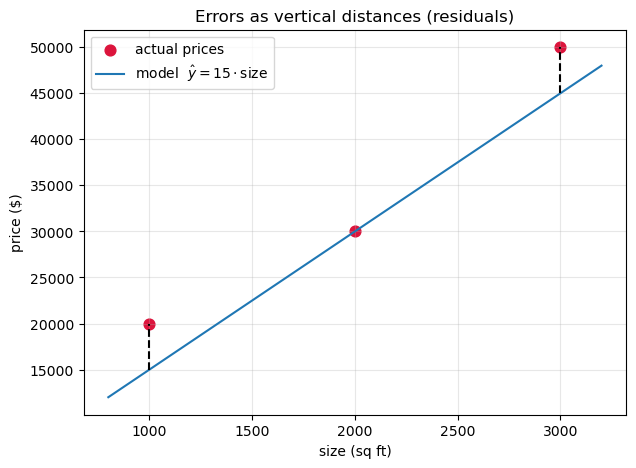

sum of signed errors : 10000.0  <- cancellation can hide bad fits


In [2]:
xs = np.linspace(800, 3200, 100)

plt.figure(figsize=(7, 5))
plt.scatter(size, actual, s=60, color="crimson", label="actual prices")
plt.plot(xs, w * xs, label=r"model  $\hat{y}=15\cdot$size")
# residual (error) segments
for s, y, yh in zip(size, actual, pred):
    plt.plot([s, s], [yh, y], "k--", linewidth=1.5)
plt.title("Errors as vertical distances (residuals)")
plt.xlabel("size (sq ft)"); plt.ylabel("price ($)")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

print("sum of signed errors :", (actual - pred).sum(), " <- cancellation can hide bad fits")

## 4. Squaring the error → the loss function

To remove the sign, we **square** the error. And in machine learning we multiply by
$\tfrac12$:

$$
L(y, \hat{y}) = \frac12\,(y - \hat{y})^2 .
$$

> *"The one half is more cosmetic — when you take the derivative of $(y-\hat{y})^2$ you get
> a lingering 2, so the $\tfrac12$ cancels it. You can multiply the error by any constant
> and it doesn't change the result."*

The squared error is always $\ge 0$, and **bigger mistakes are penalized more**.

In [3]:
def loss_per_point(y, y_hat):
    return 0.5 * (y - y_hat)**2

for s, y, yh in zip(size, actual, pred):
    print(f"size {s:>5.0f}: error {y - yh:>7.0f}, squared-error loss ½(y-ŷ)² = {loss_per_point(y, yh):>13,.0f}")

total_loss = loss_per_point(actual, pred).sum()
print(f"\ntotal loss = Σ ½(y-ŷ)² = {total_loss:,.0f}")

size  1000: error    5000, squared-error loss ½(y-ŷ)² =    12,500,000
size  2000: error       0, squared-error loss ½(y-ŷ)² =             0
size  3000: error    5000, squared-error loss ½(y-ŷ)² =    12,500,000

total loss = Σ ½(y-ŷ)² = 25,000,000


## 5. The goal: minimize the loss

> *"Our goal is to find the $w_1, w_2$ and $b$ that give $\hat{y}$ with the least error...
> We're going to use gradient descent to minimize $L$, and thus find the best model."*

The total loss is a function of the model's parameters. For our single-feature model
$\hat{y} = w\cdot\text{size}$ (bias $0$), the loss depends only on the slope $w$:

$$
L(w) = \frac12 \sum_i \big(y_i - w\,x_i\big)^2 .
$$

Minimizing it (the calculus from last week) gives the best slope.

best slope w* = Σxy/Σx² = 16.43  (the illustrative model used w = 15)


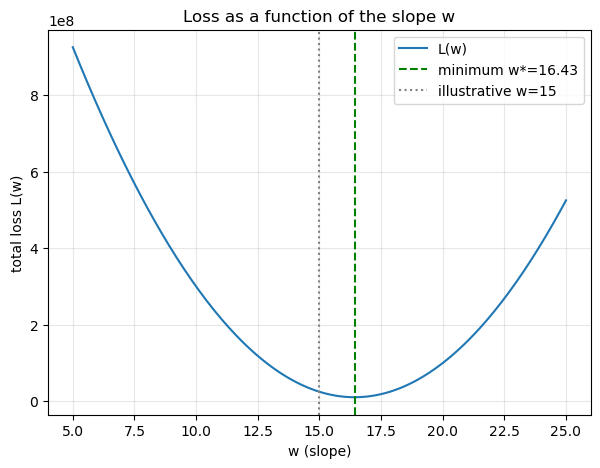

In [4]:
def total_loss_of_w(w):
    return 0.5 * np.sum((actual - w * size)**2)

w_grid = np.linspace(5, 25, 200)
losses = [total_loss_of_w(w) for w in w_grid]

# minimizer of Σ½(y - w x)^2 is w* = Σ x y / Σ x^2
w_best = np.sum(size * actual) / np.sum(size**2)
print(f"best slope w* = Σxy/Σx² = {w_best:.2f}  (the illustrative model used w = 15)")

plt.figure(figsize=(7, 5))
plt.plot(w_grid, losses, label="L(w)")
plt.axvline(w_best, color="green", linestyle="--", label=f"minimum w*={w_best:.2f}")
plt.axvline(15, color="gray", linestyle=":", label="illustrative w=15")
plt.title("Loss as a function of the slope w")
plt.xlabel("w (slope)"); plt.ylabel("total loss L(w)")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 6. Exercises

### Basic
1. Write the per-point loss function $L(y, \hat{y})$.
2. Why do we square the error instead of just adding $y - \hat{y}$?

### Intermediate
3. For the illustrative model $\hat{y} = 15\cdot\text{size}$, compute the squared-error
   loss of each house and the total.
4. Why is the $\tfrac12$ factor included, and does it change the optimal parameters?

### Advanced
5. Show that the slope minimizing $L(w) = \tfrac12\sum_i (y_i - w x_i)^2$ is
   $w^\star = \dfrac{\sum_i x_i y_i}{\sum_i x_i^2}$, and compute it for the house data.
6. The total loss $L(w)$ is a parabola in $w$. What does that guarantee about its minimum,
   and how does it connect to gradient descent?

## 7. Solutions / Checks

In [5]:
# 3.
losses3 = loss_per_point(actual, 15*size)
print("3. per-house loss:", losses3, " total:", losses3.sum())

# 5. closed-form slope
w_star = np.sum(size*actual)/np.sum(size**2)
print(f"5. w* = Σxy/Σx² = {w_star:.4f}")

# verify it minimizes by checking derivative L'(w*) = -Σ x (y - w x) ≈ 0
deriv = -np.sum(size*(actual - w_star*size))
print(f"   L'(w*) = {deriv:.6f}  (≈ 0 confirms the minimum)")

print("4. The ½ cancels the 2 from differentiating the square; scaling the loss by a "
      "constant doesn't move its minimum, so the optimal w1,w2,b are unchanged.")
print("6. A parabola is convex with a single minimum, so gradient descent converges to "
      "the unique best parameters.")

3. per-house loss: [12500000.        0. 12500000.]  total: 25000000.0
5. w* = Σxy/Σx² = 16.4286
   L'(w*) = -0.000000  (≈ 0 confirms the minimum)
4. The ½ cancels the 2 from differentiating the square; scaling the loss by a constant doesn't move its minimum, so the optimal w1,w2,b are unchanged.
6. A parabola is convex with a single minimum, so gradient descent converges to the unique best parameters.


## 8. Conclusion

- We evaluate a model by comparing predictions $\hat{y}$ to actual values $y$.
- The **error** $y - \hat{y}$ is signed, so positives and negatives can cancel — we
  **square** it.
- The **loss function** is $L(y, \hat{y}) = \tfrac12 (y - \hat{y})^2$; the $\tfrac12$ is a
  convenience that cancels the derivative's 2 and changes nothing essential.
- **Training** = minimizing the total loss over the parameters $w_1, w_2, b$, which we do
  with **gradient descent** — the next lecture.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/opt_nns_2.mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 3) lecture on the **loss function**. Key spoken points, lightly cleaned:

> With the house data and the best-fit line as our model, we need to evaluate it. The model
> predicts 15,000 / 30,000 / 45,000 for the three houses (actual 20,000 / 30,000 /
> 50,000) — it nailed the second and was close on the others. To quantify the gap, the
> error is $y - \hat{y}$, shown as vertical broken lines; shorter is better. But the error
> is positive above the line and negative below, so summing can cancel to a misleadingly
> small number. So we square it, $(y-\hat{y})^2$, and in machine learning multiply by a
> half — cosmetic, because differentiating the square leaves a 2 that the $\tfrac12$
> cancels (any constant multiple leaves the result unchanged). The loss is
> $L(y,\hat{y}) = \tfrac12 (y-\hat{y})^2$, and the goal is to find the $w_1, w_2, b$ that
> minimize it — which we'll do next with gradient descent.